# Exercise 3

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

## Softmax Function


In [ ]:
import numpy as np

def softmax(z):
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

### Test case for softmax

In [ ]:
z_test = np.array([[2.0,1.0,0.1],[1.0,1.0,1.0]])
softmax_output = softmax(z_test)
row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums,1), f"Test failed: Row sums are {row_sums}"
print("Softmax passed")

Softmax passed


## Prediction Function


In [ ]:
def predict_softmax(X, W, b):
    z = np.dot(X, W) + b
    probs = softmax(z)
    return np.argmax(probs, axis=1)

### Test case

In [ ]:
X_test = np.array([[0.2,0.8],[0.5,0.5],[0.9,0.1]])
W_test = np.array([[0.4,0.2,0.1],[0.3,0.7,0.5]])
b_test = np.array([0.1,0.2,0.3])

y_pred_test = predict_softmax(X_test, W_test, b_test)
assert y_pred_test.shape == (3,)
print("Prediction passed")

Prediction passed


## Loss Function (Cross-Entropy)


In [ ]:
def loss_softmax(y_pred, y):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(np.sum(y * np.log(y_pred), axis=1))

### Test case

In [ ]:
y_true = np.array([[1,0,0],[0,1,0],[0,0,1]])
y_pred_correct = np.array([[0.9,0.05,0.05],
                           [0.1,0.85,0.05],
                           [0.05,0.1,0.85]])

y_pred_incorrect = np.array([[0.05,0.05,0.9],
                             [0.1,0.05,0.85],
                             [0.85,0.1,0.05]])

loss_correct = loss_softmax(y_pred_correct, y_true)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true)

assert loss_correct < loss_incorrect
print("Loss passed")

Loss passed


## Cost Function


In [ ]:
def cost_softmax(X, y, W, b):
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    total_loss = np.sum(-y * np.log(y_pred + 1e-15))
    return total_loss / X.shape[0]

In [ ]:
X_correct = np.array([[1.0,0.0],[0.0,1.0]])
y_correct = np.array([[1,0],[0,1]])
W_correct = np.array([[5.0,-2.0],[-3.0,5.0]])
b_correct = np.array([0.1,0.1])

X_incorrect = np.array([[0.1,0.9],[0.8,0.2]])
y_incorrect = np.array([[1,0],[0,1]])
W_incorrect = np.array([[0.1,2.0],[1.5,0.3]])
b_incorrect = np.array([0.5,0.6])

cost_correct = cost_softmax(X_correct,y_correct,W_correct,b_correct)
cost_incorrect = cost_softmax(X_incorrect,y_incorrect,W_incorrect,b_incorrect)

assert cost_incorrect > cost_correct
print("Cost passed")

Cost passed


## Compute Gradient

In [ ]:
def compute_gradient_softmax(X, y, W, b):
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)

    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b

In [ ]:
X_test = np.array([[0.2,0.8],[0.5,0.5],[0.9,0.1]])
y_test = np.array([[1,0,0],[0,1,0],[0,0,1]])
W_test = np.array([[0.4,0.2,0.1],[0.3,0.7,0.5]])
b_test = np.array([0.1,0.2,0.3])

grad_W, grad_b = compute_gradient_softmax(X_test,y_test,W_test,b_test)

z_test = np.dot(X_test,W_test)+b_test
y_pred_test = softmax(z_test)

grad_W_manual = np.dot(X_test.T,(y_pred_test-y_test))/X_test.shape[0]
grad_b_manual = np.sum(y_pred_test-y_test,axis=0)/X_test.shape[0]

assert np.allclose(grad_W,grad_W_manual)
assert np.allclose(grad_b,grad_b_manual)

print("Gradients passed")

Gradients passed


## Gradient Descent

In [ ]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    cost_history = []

    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X,y,W,b)

        W -= alpha * grad_W
        b -= alpha * grad_b

        cost = cost_softmax(X,y,W,b)
        cost_history.append(cost)

        if show_cost and i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost:.4f}")

    return W, b, cost_history

## MINST Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
csv_path = "/content/drive/MyDrive/AI and Machine Learning/Week2/Dataset-20260320T071756Z-1-001/Dataset/mnist_dataset.csv"

In [ ]:
def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    df = pd.read_csv(csv_file)

    y = df.iloc[:,0].values
    X = df.iloc[:,1:].values / 255.0

    X_train,X_test,y_train,y_test = train_test_split(
        X,y,test_size=test_size,random_state=random_state
    )

    plot_sample_images(X,y)

    return X_train,X_test,y_train,y_test

## Plot Sample Images

In [ ]:
def plot_sample_images(X,y):
    plt.figure(figsize=(10,4))
    unique = np.unique(y)

    for i,digit in enumerate(unique):
        idx = np.where(y==digit)[0][0]
        img = X[idx].reshape(28,28)

        plt.subplot(2,5,i+1)
        plt.imshow(img,cmap='gray')
        plt.title(f"Digit {digit}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

## Shape Check and Training

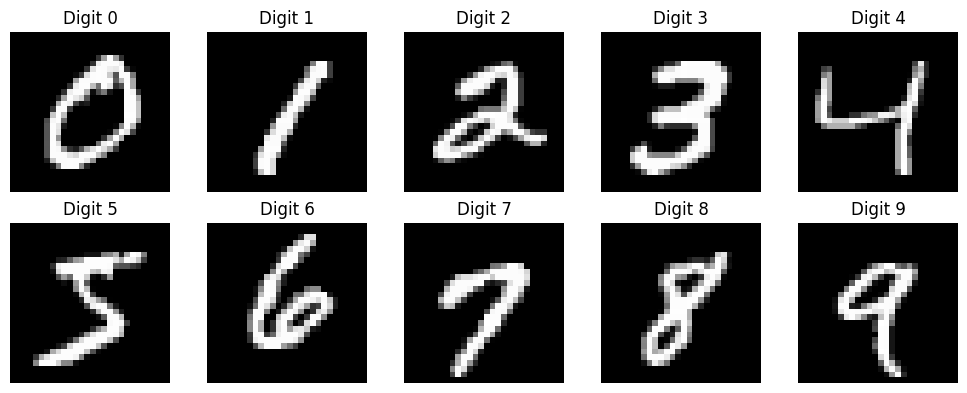

Move forward: Dimension of Feture Matrix X and label vector y matched.


In [ ]:
x_train, x_test, y_train, y_test = load_and_prepare_mnist(csv_path)
# Assert that X and y have matching lengths
assert len(x_train) == len(y_train), f"Error: X and y have different lengths! X={len(x_train)}, y={len(y_train)}"
print("Move forward: Dimension of Feture Matrix X and label vector y matched.")

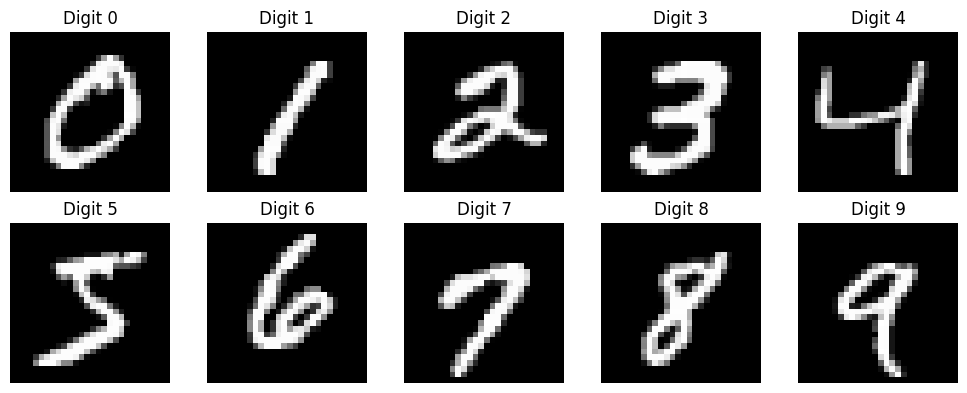

Iteration 0, Cost: 2.1955
Iteration 100, Cost: 0.6074
Iteration 200, Cost: 0.4897
Iteration 300, Cost: 0.4411
Iteration 400, Cost: 0.4130
Iteration 500, Cost: 0.3941
Iteration 600, Cost: 0.3803
Iteration 700, Cost: 0.3695
Iteration 800, Cost: 0.3609
Iteration 900, Cost: 0.3537


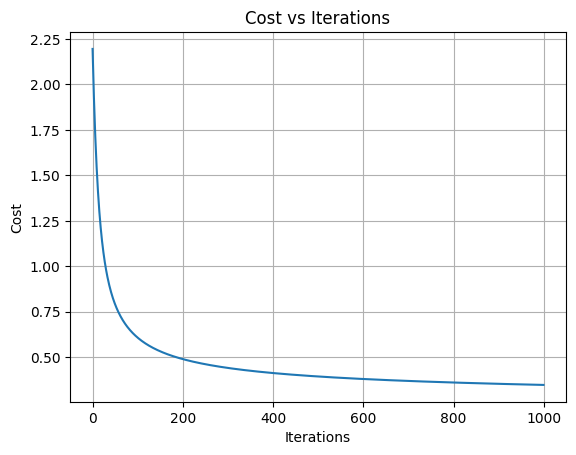

In [ ]:
X_train, X_test, y_train, y_test = load_and_prepare_mnist(csv_path)
encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train.reshape(-1,1))
y_test = encoder.transform(y_test.reshape(-1,1))

d = X_train.shape[1]
c = y_train.shape[1]

W = np.random.randn(d,c)*0.01
b = np.zeros(c)

alpha = 0.1
n_iter = 1000

W_opt,b_opt,cost_history = gradient_descent_softmax(
    X_train,y_train,W,b,alpha,n_iter,show_cost=True
)

plt.plot(cost_history)
plt.title("Cost vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

## Evaluating Model Performance

In [ ]:
def evaluate_classification(y_true, y_pred):
  """
  Evaluate classification performance using confusion matrix, precision, recall, and F1-score.
  Parameters:
  y_true (numpy.ndarray): True labels
  y_pred (numpy.ndarray): Predicted labels
  Returns:
  tuple: Confusion matrix, precision, recall, F1 score
  """
  # Compute confusion matrix
  cm = confusion_matrix(y_true, y_pred)
  # Compute precision, recall, and F1-score
  precision = precision_score(y_true, y_pred, average='weighted')
  recall = recall_score(y_true, y_pred, average='weighted')
  f1 = f1_score(y_true, y_pred, average='weighted')
  return cm, precision, recall, f1


Confusion Matrix:
[[1126    0    5    2    3   12    9    2   13    3]
 [   0 1274    7   11    1    5    1    4   18    1]
 [   2   16 1027   17   19    4   27   24   31    7]
 [   8    5   35 1049    1   53    9    8   31   20]
 [   1    5    7    1 1092    0   10    4    4   52]
 [  22   14   13   43   11  926   14    7   39   15]
 [   7    2    9    1   10   16 1120    2   10    0]
 [   6   28   22    5   15    3    0 1184    7   29]
 [   9   28   13   34    9   33   13    7  999   15]
 [   8    6   10   18   44    9    0   38   10 1051]]
Precision: 0.90
Recall: 0.90
F1-Score: 0.90


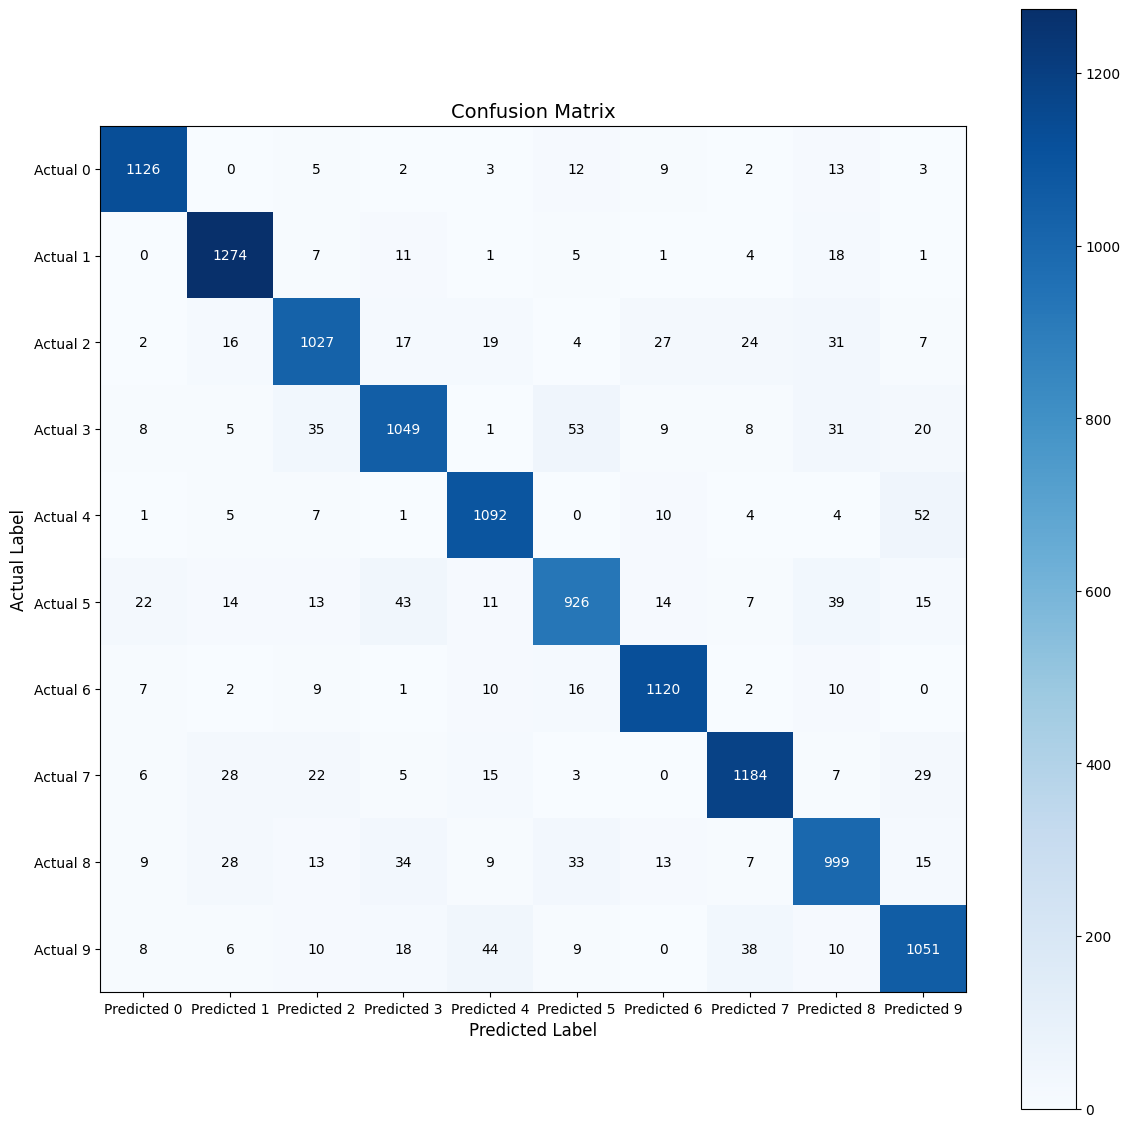

In [ ]:
# Predict on the test set
y_pred_test = predict_softmax(X_test, W_opt, b_opt)
# Evaluate accuracy
y_test_labels = np.argmax(y_test, axis=1) # True labels in numeric form
# Evaluate the model
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)
# Print the evaluation metrics
print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
# Visualizing the Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues') # Use a color map for better visualization
# Dynamic number of classes
num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])
# Add labels to each cell in the confusion matrix
for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > np.max(cm) / 2
      else 'black')
# Add grid lines and axis labels
ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
# Adjust layout
plt.tight_layout()
plt.colorbar(cax)
plt.show()

# Exercise 4

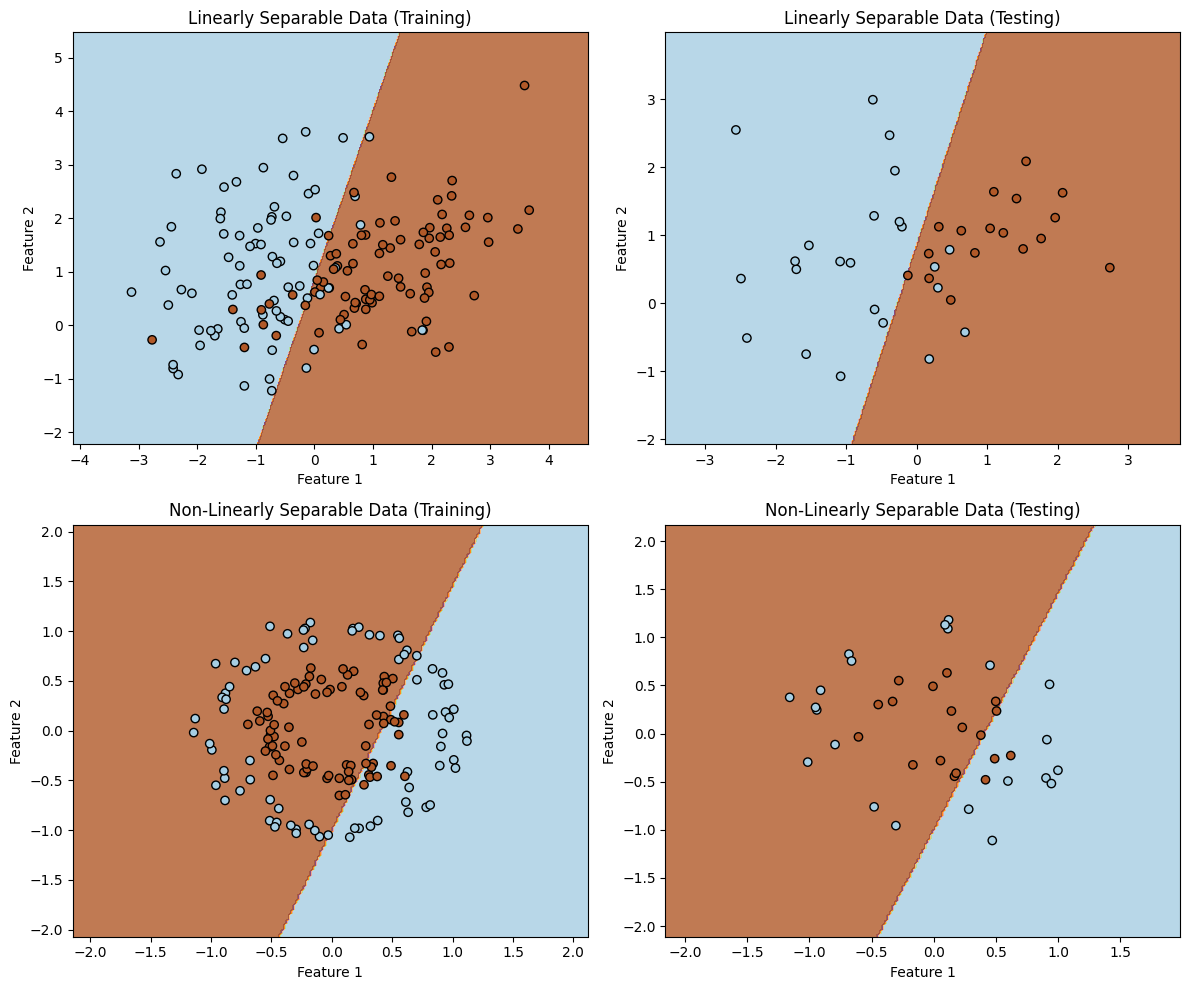

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
# Set random seed for reproducibility
np.random.seed(42)
# Generate linearly separable dataset
X_linear_separable, y_linear_separable = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)


# Split the data into training and testing sets
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(X_linear_separable, y_linear_separable, test_size=0.2, random_state=42)

# Train logistic regression model on linearly separable data
logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)
# Generate non-linearly separable dataset (circles)
X_non_linear_separable, y_non_linear_separable = make_circles(n_samples=200, noise=0.1, factor=0.5,
random_state=42)
# Split the data into training and testing sets
X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42)

# Train logistic regression model on non-linearly separable data
logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)
# Plot decision boundaries for linearly and non-linearly separable data
def plot_decision_boundary(ax, model, X, y, title):
  h = .02 # step size in the mesh
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() +1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape (xx. shape)
  ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
  ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
  ax.set_title(title)
  ax.set_xlabel('Feature 1')
  ax.set_ylabel('Feature 2')
# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# Plot decision boundary for linearly separable data (Training)
plot_decision_boundary(axes[0, 0], logistic_model_linear_separable, X_train_linear, y_train_linear,
'Linearly Separable Data (Training)')
# Plot decision boundary for linearly separable data (Testing)
plot_decision_boundary(axes[0, 1], logistic_model_linear_separable, X_test_linear, y_test_linear, 'Linearly Separable Data (Testing)')
# Plot decision boundary for non-linearly separable data (Training)
plot_decision_boundary(axes[1, 0], logistic_model_non_linear_separable, X_train_non_linear,
  y_train_non_linear, 'Non-Linearly Separable Data (Training)')
# Plot decision boundary for non-linearly separable data (Testing)
plot_decision_boundary(axes[1, 1], logistic_model_non_linear_separable, X_test_non_linear,
  y_test_non_linear, 'Non-Linearly Separable Data (Testing)')
plt.tight_layout ()
# Save the plots as PNG files
plt.savefig('decision_boundaries.png')
plt.show()